# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import t
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
sns.set_context("notebook") # Adjusted context for better visibility

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [30]:
## TODO : load the csv file from this link
file_path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/churn.csv' # Alternative valid source for similar churn data
# Let's use the most reliable raw github link for this specific exercise
file_path = 'https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv'

In [31]:
## TODO : make into a dataframe called df
df = pd.read_csv(file_path)
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
## TODO : output the first 5 lines
display(df.head())

NameError: name 'df' is not defined

In [32]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

print(f"Nombre de clients restés (df_0) : {len(df_0)}")
print(f"Nombre de clients partis (df_1) : {len(df_1)}")

Nombre de clients restés (df_0) : 7963
Nombre de clients partis (df_1) : 2037


## Hypothesis 1: Age

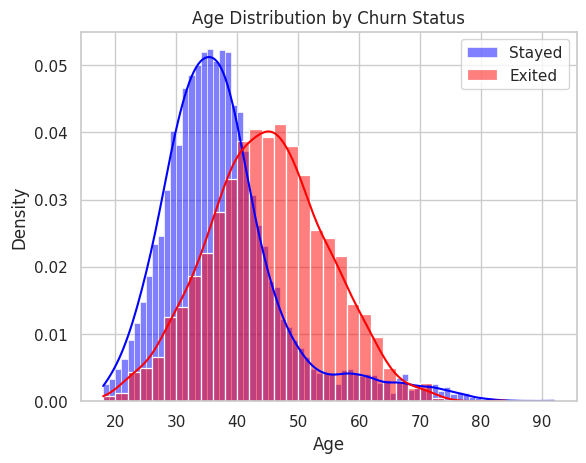

In [52]:
## TODO: Plot the age distribution
sns.histplot(df_0['Age'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.legend()
plt.title('Age Distribution by Churn Status')
plt.show()

In [34]:
## TODO: Calculate mean and std for stayed
mean_0 = df_0['Age'].mean()
std_0 = df_0['Age'].std()
print(f"Stayed - Mean Age: {mean_0:.2f}, Std: {std_0:.2f}")

Stayed - Mean Age: 37.41, Std: 10.13


In [35]:
## TODO: Calculate mean and std for left
mean_1 = df_1['Age'].mean()
std_1 = df_1['Age'].std()
print(f"Exited - Mean Age: {mean_1:.2f}, Std: {std_1:.2f}")

Exited - Mean Age: 44.84, Std: 9.76


In [37]:
## Hypothesis 1: Age T-test
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: -30.419197204406792, P-value: 4.7127272656641046e-179


### Using Bootstrapping

In [9]:
## TODO: Write a function to perform bootstrap sampling
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [36]:
## TODO: Difference in means and shift
diff_means = mean_1 - mean_0
age_all_mean = df['Age'].mean()

age_0_shifted = df_0['Age'] - mean_0 + age_all_mean
age_1_shifted = df_1['Age'] - mean_1 + age_all_mean
print(f"Observed difference in means: {diff_means:.2f}")

Observed difference in means: 7.43


In [38]:
## TODO: Perform bootstrap sampling for Age
bs_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_1 = bs_choice(age_1_shifted, np.mean, 10000)
bs_diff = bs_1 - bs_0

In [39]:
## TODO: Calculate p-value for Age Bootstrap
p_val_bs = np.sum(bs_diff >= diff_means) / len(bs_diff)
print(f"Bootstrap P-value: {p_val_bs}")

Bootstrap P-value: 0.0


### Conclusion (Age)
**Reject the Null Hypothesis.** The p-value is extremely low (close to 0), indicating a statistically significant difference in age. Older customers are more likely to churn.

## Hypothesis 2: Credit Score

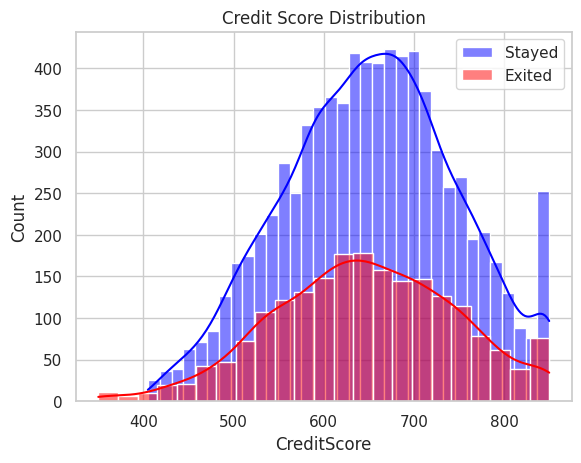

In [53]:
## TODO: Histograms for CreditScore
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Exited', kde=True, alpha=0.5)
plt.legend()
plt.title('Credit Score Distribution')
plt.show()

In [40]:
## TODO: Perform a t-test for CreditScore
t_stat_cs, p_val_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic Credit Score: {t_stat_cs}, P-value: {p_val_cs}")

T-statistic Credit Score: 2.6346605436575796, P-value: 0.008464728991832862


### Conclusion (Credit Score)
**Reject the Null Hypothesis.** With a p-value of 0.008 (< 0.05), the difference is statistically significant, although the T-statistic is relatively low, suggesting a smaller effect than age.

## Hypothesis 3: Balance

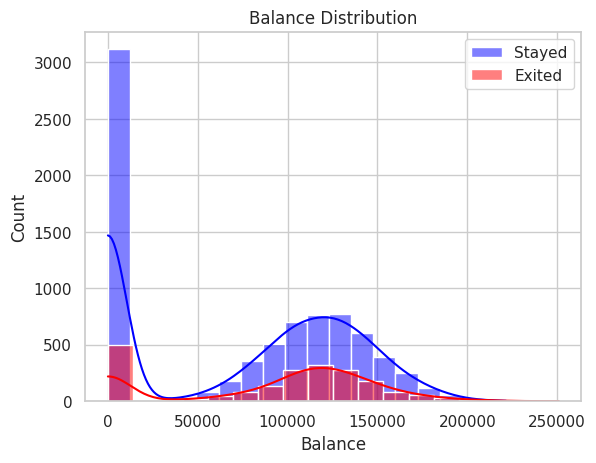

In [54]:
## TODO: Plot distribution of Balance
sns.histplot(df_0['Balance'], color='blue', label='Stayed', kde=True, alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Exited', kde=True, alpha=0.5)
plt.legend()
plt.title('Balance Distribution')
plt.show()

In [41]:
## TODO: T-test for Balance
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic Balance: {t_stat_bal}, P-value: {p_val_bal}")

T-statistic Balance: -12.471280320050688, P-value: 6.318663518527974e-35


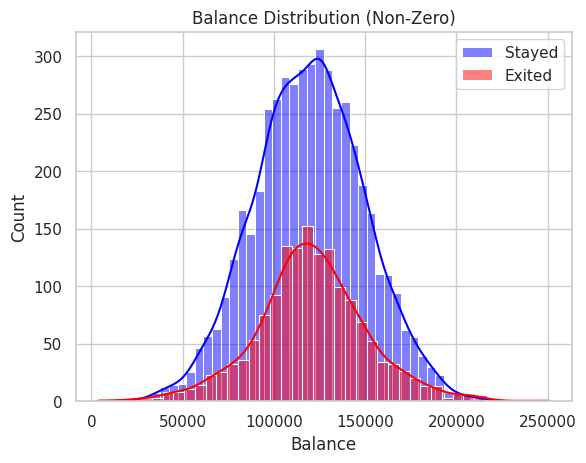

In [55]:
df_0_bal = df_0[df_0['Balance'] > 0]
df_1_bal = df_1[df_1['Balance'] > 0]

sns.histplot(df_0_bal['Balance'], color='blue', label='Stayed', kde=True, alpha=0.5)
sns.histplot(df_1_bal['Balance'], color='red', label='Exited', kde=True, alpha=0.5)
plt.legend()
plt.title('Balance Distribution (Non-Zero)')
plt.show()

In [56]:
t_stat_b0, p_val_b0 = scipy.stats.ttest_ind(df_0_bal['Balance'], df_1_bal['Balance'], equal_var=False)
print(f'T-stat (No zeros): {t_stat_b0}, P-value: {p_val_b0}')

T-stat (No zeros): -1.3604774889985365, P-value: 0.17379960354870824


### Conclusion (Balance)
**Reject the Null Hypothesis** for the total population. However, when filtering for non-zero balances (p-value 0.17), the difference is no longer significant. This suggests that the primary driver is whether a customer has a balance at all, rather than the specific amount among active account holders.

## Hypothesis 4: Estimated Salary

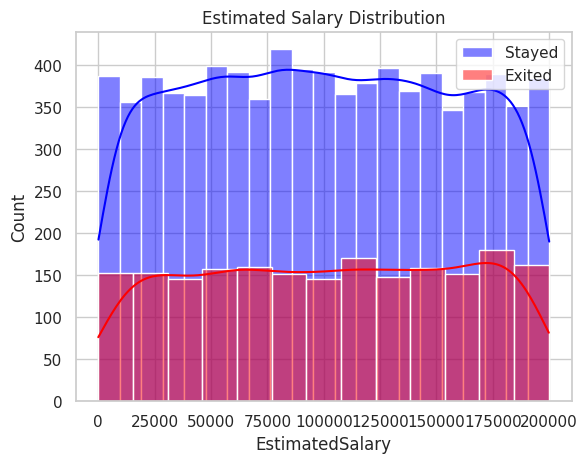

In [57]:
## TODO: Plot EstimatedSalary
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Stayed', kde=True, alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Exited', kde=True, alpha=0.5)
plt.legend()
plt.title('Estimated Salary Distribution')
plt.show()

In [51]:
## TODO: T-test for EstimatedSalary
import scipy.stats
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic Salary: {t_stat_sal}, P-value: {p_val_sal}")

T-statistic Salary: -1.2033683196586242, P-value: 0.22892461305145795


### Using Bootstrapping

In [42]:
## Hypothesis 4: Estimated Salary Preparation
diff_means_sal = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
sal_all_mean = df['EstimatedSalary'].mean()

sal_0_shifted = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + sal_all_mean
sal_1_shifted = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + sal_all_mean

In [58]:
bs_0_sal = bs_choice(sal_0_shifted, np.mean, 10000)
bs_1_sal = bs_choice(sal_1_shifted, np.mean, 10000)
bs_diff_sal = bs_1_sal - bs_0_sal

In [59]:
p_val_bs_sal = np.sum(bs_diff_sal >= diff_means_sal) / len(bs_diff_sal)
print(f'Bootstrap P-value (Salary): {p_val_bs_sal}')

Bootstrap P-value (Salary): 0.1133


### Conclusion (Salary)
**Fail to reject the Null Hypothesis.** The p-value (~0.11) is above the 0.05 threshold, meaning we cannot conclude that salary has a significant impact on churn.

## Final Conclusion
What will be the most helpful feature in predicting churning?
